<a href="https://colab.research.google.com/github/class177/Exercise_3.1/blob/main/HW3_1_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

!nvidia-smi

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Fri May  8 08:47:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                      

In [ ]:
# Clone 書本 repo
!git clone https://github.com/le-liang/wcmlbook.git

# Clone 原作者 repo (含 channel dataset)
!git clone https://github.com/haoyye/OFDM_DNN.git

# 檢視檔案
!ls wcmlbook/ch3/Exercise_3.1/
!ls OFDM_DNN/

Cloning into 'wcmlbook'...
remote: Enumerating objects: 1976, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 1976 (delta 21), reused 12 (delta 12), pack-reused 1945 (from 4)
Receiving objects: 100% (1976/1976), 153.37 MiB | 24.70 MiB/s, done.
Resolving deltas: 100% (827/827), done.
Cloning into 'OFDM_DNN'...
remote: Enumerating objects: 62, done.
remote: Total 62 (delta 0), reused 0 (delta 0), pack-reused 62 (from 1)
Receiving objects: 100% (62/62), 530.22 MiB | 46.20 MiB/s, done.
Resolving deltas: 100% (23/23), done.
DNN_Detection  H_dataset  README.md
DNN_Detection  H_dataset  ReadMe.rst


In [ ]:
import os
os.chdir('/content/wcmlbook/ch3/Exercise_3.1')
!ls
!cat main.py | head -50


DNN_Detection  H_dataset  README.md
cat: main.py: No such file or directory


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import scipy.io as sio
import os

# ============ OFDM 系統參數 ============
K = 64              # 子載波數
CP = K // 4         # CP 長度 = 16
P = 64              # Pilot 數 (會動態改)
mu = 2              # QPSK
payloadBits_per_OFDM = K * mu

# QPSK mapping
mapping_table = {
    (0,0): 1+1j, (0,1): 1-1j,
    (1,0): -1+1j, (1,1): -1-1j,
}
demapping_table = {v: k for k, v in mapping_table.items()}

# ============ 載入通道資料集 ============
# 使用 haoyye repo 內的 channel response
channel_file = '/content/OFDM_DNN/H_dataset/channel_train.npy'
if os.path.exists(channel_file):
    channel_response_set_train = np.load(channel_file)
    channel_response_set_test = np.load('/content/OFDM_DNN/H_dataset/channel_test.npy')
    print("Channel dataset loaded:",
          channel_response_set_train.shape, channel_response_set_test.shape)
else:
    # 若檔案不存在,用 Rayleigh 簡化模型
    print("⚠️ Channel dataset not found, generating synthetic Rayleigh channels...")
    L = 8  # tap 數
    channel_response_set_train = (np.random.randn(10000, L) +
                                  1j*np.random.randn(10000, L)) / np.sqrt(2*L)
    channel_response_set_test  = (np.random.randn(1000, L) +
                                  1j*np.random.randn(1000, L)) / np.sqrt(2*L)

print("✅ Channel ready")


⚠️ Channel dataset not found, generating synthetic Rayleigh channels...
✅ Channel ready


In [ ]:
def Modulation(bits):
    bit_r = bits.reshape((-1, mu))
    return np.array([mapping_table[tuple(b)] for b in bit_r])

def IDFT(OFDM_data):
    return np.fft.ifft(OFDM_data)

def addCP(OFDM_time):
    cp = OFDM_time[-CP:]
    return np.hstack([cp, OFDM_time])

def channel(signal, channelResponse, SNRdb):
    convolved = np.convolve(signal, channelResponse)
    sig_pow = np.mean(abs(convolved**2))
    noise_pow = sig_pow * 10**(-SNRdb/10)
    noise = np.sqrt(noise_pow/2) * (np.random.randn(*convolved.shape)
                                    + 1j*np.random.randn(*convolved.shape))
    return convolved + noise

def removeCP(signal):
    return signal[CP:(CP+K)]

def DFT(OFDM_RX):
    return np.fft.fft(OFDM_RX)

# Pilot pattern
Pilot_file_name = 'Pilot_' + str(P)
if os.path.isfile(Pilot_file_name):
    bits = np.loadtxt(Pilot_file_name, delimiter=',')
else:
    bits = np.random.binomial(n=1, p=0.5, size=(K*mu,))
    np.savetxt(Pilot_file_name, bits, delimiter=',')

pilotValue = Modulation(bits)

def ofdm_simulate(codeword, channelResponse, SNRdb, num_pilots):
    """生成一組 pilot+data OFDM frame,回傳接收端 (pilot, data) 實虛部"""
    # --- Pilot OFDM symbol ---
    OFDM_data_pilot = pilotValue[:K]  # 全 subcarrier 皆放 pilot
    OFDM_time_pilot = IDFT(OFDM_data_pilot)
    OFDM_withCP_pilot = addCP(OFDM_time_pilot)
    OFDM_RX_pilot = channel(OFDM_withCP_pilot, channelResponse, SNRdb)
    OFDM_RX_noCP_pilot = removeCP(OFDM_RX_pilot)

    # --- Data OFDM symbol ---
    symbol = Modulation(codeword)
    OFDM_data = symbol
    OFDM_time = IDFT(OFDM_data)
    OFDM_withCP = addCP(OFDM_time)
    OFDM_RX = channel(OFDM_withCP, channelResponse, SNRdb)
    OFDM_RX_noCP = removeCP(OFDM_RX)

    # 若 num_pilots < K,對 pilot 子載波做抽樣 (其他位置補 0 模擬)
    if num_pilots < K:
        mask = np.zeros(K, dtype=complex)
        idx = np.linspace(0, K-1, num_pilots).astype(int)
        mask[idx] = OFDM_RX_noCP_pilot[idx]
        OFDM_RX_noCP_pilot = mask
    elif num_pilots == 0:
        OFDM_RX_noCP_pilot = np.zeros(K, dtype=complex)

    return np.concatenate((
        np.concatenate((np.real(OFDM_RX_noCP_pilot), np.imag(OFDM_RX_noCP_pilot))),
        np.concatenate((np.real(OFDM_RX_noCP),       np.imag(OFDM_RX_noCP)))
    )), abs(channelResponse)


In [ ]:
def build_dnn():
    model = models.Sequential([
        layers.Input(shape=(256,)),      # 2 OFDM symbols × 64 subcarriers × 2 (real/imag)
        layers.Dense(500, activation='relu'),
        layers.Dense(250, activation='relu'),
        layers.Dense(120, activation='relu'),
        layers.Dense(16,  activation='sigmoid'),  # 預測 16 bits
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse',
        metrics=['binary_accuracy']
    )
    return model


In [ ]:
# 只預測第一組 16 bits (對應 Figure 3.3 設定)
pred_range = np.arange(0, 16)

def training_gen(bs, num_pilots, snr_train=20):
    while True:
        X_batch = np.zeros((bs, 256))
        Y_batch = np.zeros((bs, 16))
        for i in range(bs):
            bits = np.random.binomial(1, 0.5, (payloadBits_per_OFDM,))
            ch = channel_response_set_train[
                np.random.randint(len(channel_response_set_train))]
            signal, _ = ofdm_simulate(bits, ch, snr_train, num_pilots)
            X_batch[i] = signal
            Y_batch[i] = bits[pred_range]
        yield X_batch, Y_batch

def test_gen(bs, num_pilots, snr_test):
    X_batch = np.zeros((bs, 256))
    Y_batch = np.zeros((bs, 16))
    for i in range(bs):
        bits = np.random.binomial(1, 0.5, (payloadBits_per_OFDM,))
        ch = channel_response_set_test[
            np.random.randint(len(channel_response_set_test))]
        signal, _ = ofdm_simulate(bits, ch, snr_test, num_pilots)
        X_batch[i] = signal
        Y_batch[i] = bits[pred_range]
    return X_batch, Y_batch


In [ ]:
pilot_configs = [64, 8, 0]        # 64 / 8 / no-pilot (共 3 組節省時間)
snr_test_list = [5, 10, 15, 20, 25]
BER_results = {}

for num_pilots in pilot_configs:
    print(f"\n{'='*50}")
    print(f"🏗️  Training DNN with Pilots = {num_pilots}")
    print('='*50)

    model = build_dnn()

    # 訓練
    model.fit(
        training_gen(1000, num_pilots, snr_train=20),
        steps_per_epoch=50,
        epochs=20,              # 為節省時間用 20,若要更準可改 100+
        verbose=1
    )

    # 測試不同 SNR
    ber_list = []
    for snr in snr_test_list:
        X_test, Y_test = test_gen(10000, num_pilots, snr)
        Y_pred = model.predict(X_test, verbose=0)
        Y_pred_bits = (Y_pred > 0.5).astype(int)
        ber = np.mean(Y_pred_bits != Y_test)
        ber_list.append(ber)
        print(f"  SNR = {snr:2d} dB  →  BER = {ber:.4e}")

    BER_results[num_pilots] = ber_list

print("\n✅ All simulations done!")
print(BER_results)



🏗️  Training DNN with Pilots = 64
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 295ms/step - binary_accuracy: 0.5709 - loss: 0.2449
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 321ms/step - binary_accuracy: 0.7928 - loss: 0.1710
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - binary_accuracy: 0.9241 - loss: 0.0763
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 309ms/step - binary_accuracy: 0.9630 - loss: 0.0406
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - binary_accuracy: 0.9722 - loss: 0.0290
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - binary_accuracy: 0.9767 - loss: 0.0234
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 307ms/step - binary_accuracy: 0.9792 - loss: 0.0201
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 305ms/step - binary_accuracy: 0.9809 - loss: 0.0178
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 298ms/step - binary_accuracy: 0.9825 - loss: 0.0161
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - binary_accuracy: 0.9837 - loss: 0.0147
Epoch 11/20
50/50 ━━━━━━

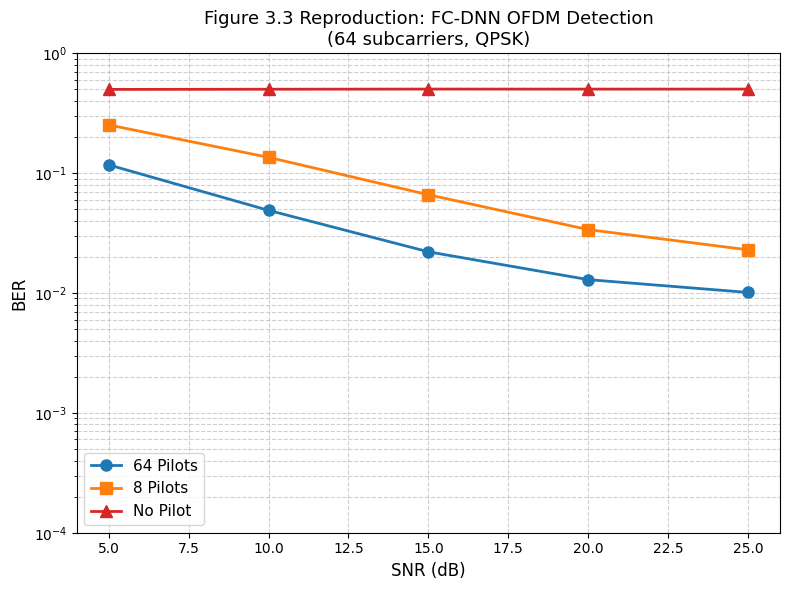

✅ 結果已儲存為 Fig3_3_reproduction.png 與 BER_results.json


In [ ]:
plt.figure(figsize=(8, 6))
markers = {64: 'o', 8: 's', 0: '^'}
colors  = {64: 'tab:blue', 8: 'tab:orange', 0: 'tab:red'}

for p, bers in BER_results.items():
    label = f"{p} Pilots" if p > 0 else "No Pilot"
    plt.semilogy(snr_test_list, bers,
                 marker=markers[p], color=colors[p],
                 linewidth=2, markersize=8, label=label)

plt.xlabel('SNR (dB)', fontsize=12)
plt.ylabel('BER', fontsize=12)
plt.title('Figure 3.3 Reproduction: FC-DNN OFDM Detection\n(64 subcarriers, QPSK)',
          fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.ylim([1e-4, 1])
plt.tight_layout()
plt.savefig('Fig3_3_reproduction.png', dpi=200)
plt.show()

# 存檔
import json
with open('BER_results.json', 'w') as f:
    json.dump({str(k): v for k, v in BER_results.items()}, f, indent=2)
print("✅ 結果已儲存為 Fig3_3_reproduction.png 與 BER_results.json")


In [ ]:
from google.colab import files
files.download('Fig3_3_reproduction.png')
files.download('BER_results.json')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>